# Regression – Task 6: Regression Tree Model

**Ziel:** Ein Regressionsbaum-Modell zur Vorhersage des *Customer Lifetime Value* (`CLV_Continuous`) trainieren, mit Cross-Validation und Hyperparameter-Tuning optimieren und anschließend auf Overfitting bzw. Underfitting analysieren.

> **Warum ein Regressionsbaum?** Entscheidungsbaeume koennen nichtlineare Zusammenhaenge und Interaktionen zwischen Variablen ohne explizite Feature-Transformation abbilden. Gleichzeitig neigen sie ohne Begrenzung der Komplexitaet stark zu Overfitting.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42

plt.rc('font', size=13)
plt.rc('axes', labelsize=13, titlesize=13)
plt.rc('legend', fontsize=12)

---
### Schritt 1: Daten laden und in Trainings- und Testdaten aufteilen

Wie in den vorherigen Tasks wird `CLV_Continuous` als Zielvariable verwendet. Die Daten werden in 80 % Trainingsdaten und 20 % Testdaten aufgeteilt.

In [14]:
# Datensatz einlesen
df = pd.read_csv('../data/dataset_cleaned.csv')

# Features und Zielvariable
X = df.drop(['Churn', 'CLV_Continuous'], axis=1)
y = df['CLV_Continuous']

# Train/Test-Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print('Trainingsdaten:', X_train.shape)
print('Testdaten:     ', X_test.shape)

Trainingsdaten: (6816, 22)
Testdaten:      (1705, 22)


---
### Schritt 2: Baseline – unregularisierter Regressionsbaum

Zunaechst wird ein einfacher Entscheidungsbaum mit Standardparametern trainiert. Diese Baseline zeigt, wie stark ein unbeschraenkter Baum zum Overfitting neigen kann.

In [15]:
# Baseline-Modell
tree_baseline = DecisionTreeRegressor(random_state=RANDOM_STATE)
tree_baseline.fit(X_train, y_train)

y_pred_train_base = tree_baseline.predict(X_train)
y_pred_test_base = tree_baseline.predict(X_test)

baseline_results = {
    'Train MAE': mean_absolute_error(y_train, y_pred_train_base),
    'Test MAE': mean_absolute_error(y_test, y_pred_test_base),
    'Train RMSE': np.sqrt(mean_squared_error(y_train, y_pred_train_base)),
    'Test RMSE': np.sqrt(mean_squared_error(y_test, y_pred_test_base)),
    'Train R2': r2_score(y_train, y_pred_train_base),
    'Test R2': r2_score(y_test, y_pred_test_base),
}

print('=== Baseline: Regression Tree ===')
for metric, value in baseline_results.items():
    print(f'{metric:<12}: {value:.4f}')

=== Baseline: Regression Tree ===
Train MAE   : 0.0000
Test MAE    : 677.2977
Train RMSE  : 0.0000
Test RMSE   : 969.1376
Train R2    : 1.0000
Test R2     : 0.9685


---
### Schritt 3: Hyperparameter-Tuning mit Cross-Validation

Entscheidungsbaeume werden stark von ihrer Komplexitaet bestimmt. Deshalb werden zentrale Hyperparameter per **GridSearchCV** optimiert:

- `max_depth`: maximale Baumtiefe
- `min_samples_split`: minimale Anzahl an Beobachtungen fuer einen Split
- `min_samples_leaf`: minimale Anzahl an Beobachtungen pro Blatt
- `max_features`: Anzahl beruecksichtigter Features pro Split
- `ccp_alpha`: Cost-Complexity-Pruning zur Reduktion von Overfitting

**Cross-Validation:** 5-fach  
**Optimierungsziel:** Minimierung des RMSE auf Validierungsdaten

In [16]:
param_grid = {
    'max_depth': [3, 5, 7, 10, 15, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'max_features': [None, 'sqrt', 'log2'],
    'ccp_alpha': [0.0, 0.0001, 0.001, 0.01, 0.1]
}

grid_search = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=RANDOM_STATE),
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=5,
    n_jobs=-1,
    refit=True
)

grid_search.fit(X_train, y_train)

best_tree_model = grid_search.best_estimator_
best_params = grid_search.best_params_
best_cv_rmse = -grid_search.best_score_

print('=== GridSearchCV – Beste Konfiguration ===')
print('Beste Parameter:', best_params)
print(f'Bester CV-RMSE: {best_cv_rmse:.4f}')

=== GridSearchCV – Beste Konfiguration ===
Beste Parameter: {'ccp_alpha': 0.0, 'max_depth': 15, 'max_features': None, 'min_samples_leaf': 5, 'min_samples_split': 20}
Bester CV-RMSE: 1004.4807


---
### Schritt 4: Optimierten Regressionsbaum evaluieren

Nun wird das beste Modell auf Trainings- und Testdaten bewertet und direkt mit der Baseline verglichen.

In [17]:
# Vorhersagen des optimierten Modells
y_pred_train_tree = best_tree_model.predict(X_train)
y_pred_test_tree = best_tree_model.predict(X_test)

tree_results = {
    'Train MAE': mean_absolute_error(y_train, y_pred_train_tree),
    'Test MAE': mean_absolute_error(y_test, y_pred_test_tree),
    'Train RMSE': np.sqrt(mean_squared_error(y_train, y_pred_train_tree)),
    'Test RMSE': np.sqrt(mean_squared_error(y_test, y_pred_test_tree)),
    'Train R2': r2_score(y_train, y_pred_train_tree),
    'Test R2': r2_score(y_test, y_pred_test_tree),
}

comparison_df = pd.DataFrame([
    ['Baseline Regression Tree', *baseline_results.values(), baseline_results['Train R2'] - baseline_results['Test R2']],
    ['Optimized Regression Tree', *tree_results.values(), tree_results['Train R2'] - tree_results['Test R2']]
], columns=['Modell', 'Train MAE', 'Test MAE', 'Train RMSE', 'Test RMSE', 'Train R2', 'Test R2', 'R2-Gap'])

comparison_df = comparison_df.set_index('Modell')
comparison_df

,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2,R2-Gap
Modell,,,,,,,
Baseline Regression Tree,0.000000,677.297672,0.000000,969.137630,1.000000,0.968473,0.031527
Optimized Regression Tree,447.110481,652.420680,632.777976,889.623559,0.986498,0.973434,0.013064


---
### Schritt 5: Visualisierungen zur Modellbeurteilung

Die folgenden Plots helfen bei der Interpretation des Modells:

- GridSearchCV-Ergebnisse
- Feature Importances
- Visualisierung der oberen Baumstruktur
- Actual vs. Predicted Plot
- Residualplot

In [18]:
# 1) GridSearchCV-Ergebnisse: Top-10 Kombinationen
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results['rmse'] = -cv_results['mean_test_score']

cv_results[['param_max_depth', 'param_min_samples_split', 'param_min_samples_leaf', 'param_max_features', 'param_ccp_alpha', 'rmse']]\
    .sort_values('rmse')\
    .head(10)

,param_max_depth,param_min_samples_split,param_min_samples_leaf,param_max_features,param_ccp_alpha,rmse
827,None,20,5,None,0.0010,1004.480706
1067,15,20,5,None,0.0100,1004.480706
1355,15,20,5,None,0.1000,1004.480706
491,15,20,5,None,0.0001,1004.480706
779,15,20,5,None,0.0010,1004.480706
1115,None,20,5,None,0.0100,1004.480706
251,None,20,5,None,0.0000,1004.480706
539,None,20,5,None,0.0001,1004.480706
203,15,20,5,None,0.0000,1004.480706
1403,None,20,5,None,0.1000,1004.480706


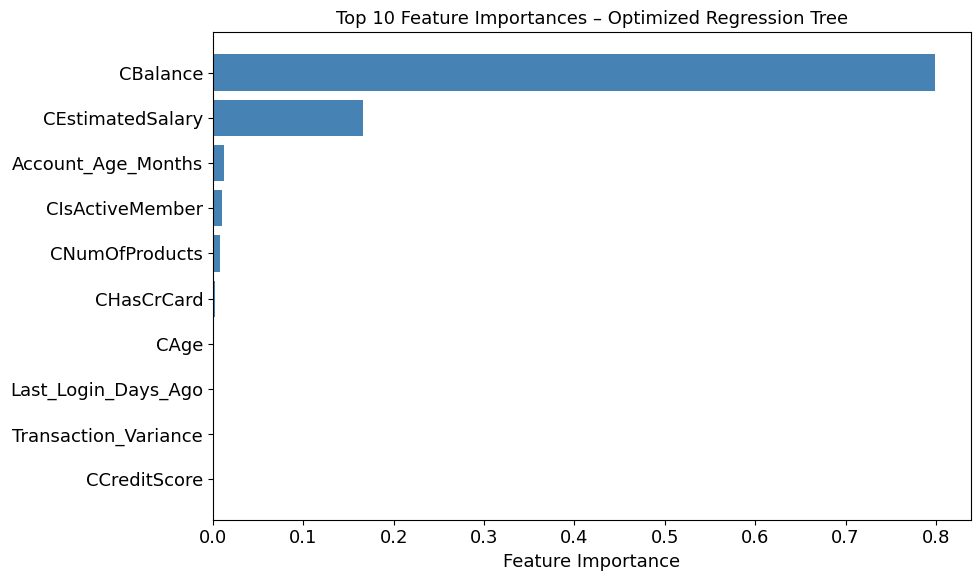

CBalance                0.798779
CEstimatedSalary        0.166157
Account_Age_Months      0.012875
CIsActiveMember         0.009834
CNumOfProducts          0.008011
CHasCrCard              0.002818
CAge                    0.000398
Last_Login_Days_Ago     0.000234
Transaction_Variance    0.000192
CCreditScore            0.000179
dtype: float64

In [19]:
# 2) Feature Importances
feature_importances = pd.Series(best_tree_model.feature_importances_, index=X.columns).sort_values(ascending=False)
top10_features = feature_importances.head(10).sort_values()

plt.figure(figsize=(10, 6))
plt.barh(top10_features.index, top10_features.values, color='steelblue')
plt.xlabel('Feature Importance')
plt.title('Top 10 Feature Importances – Optimized Regression Tree')
plt.tight_layout()
plt.show()

feature_importances.head(10)

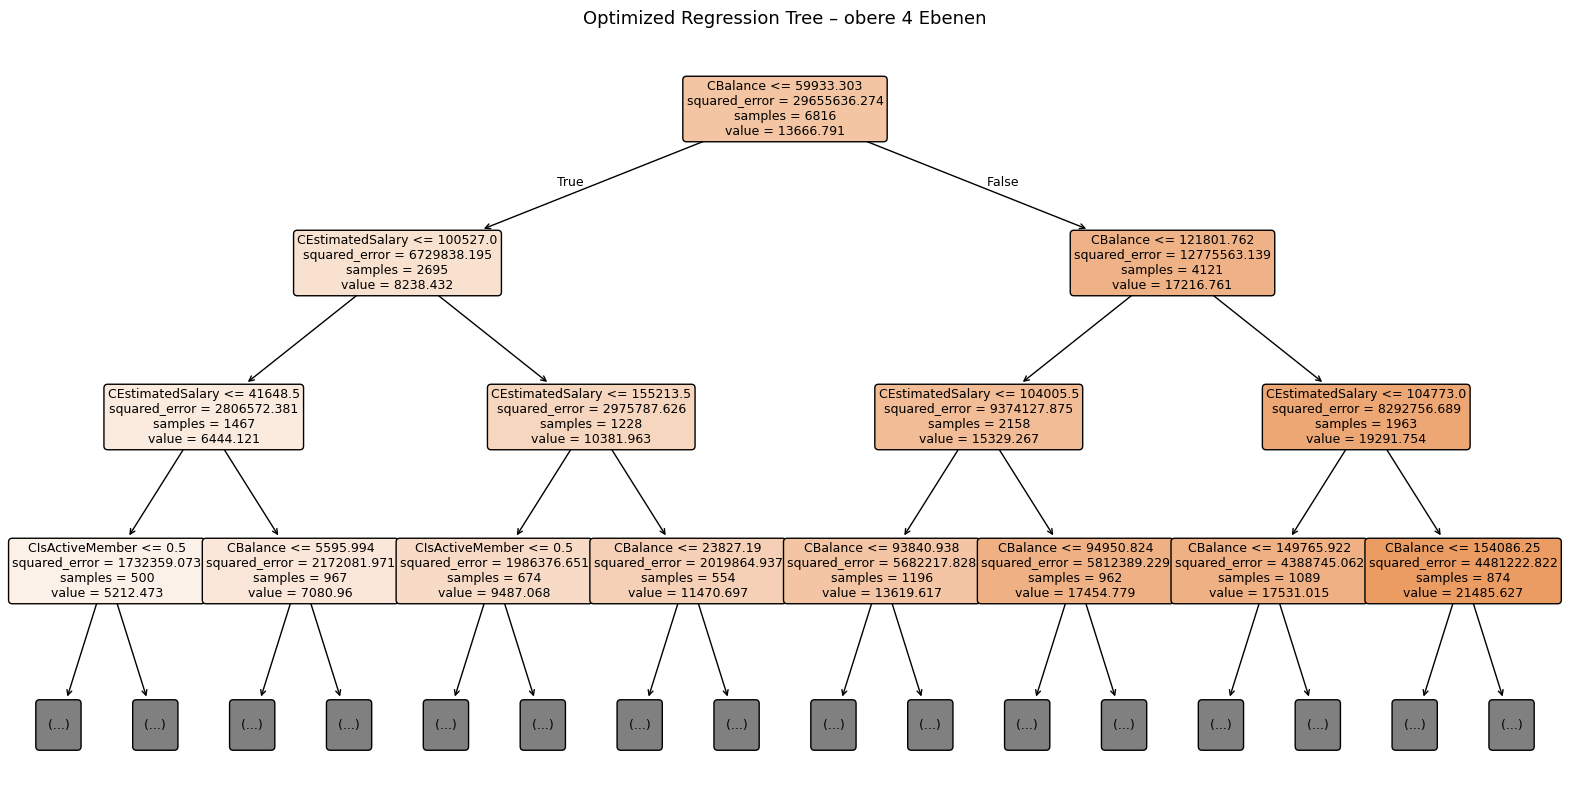

In [20]:
# 3) Obere Baumstruktur visualisieren
plt.figure(figsize=(20, 10))
plot_tree(
    best_tree_model,
    feature_names=X.columns,
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=9
)
plt.title('Optimized Regression Tree – obere 4 Ebenen')
plt.show()

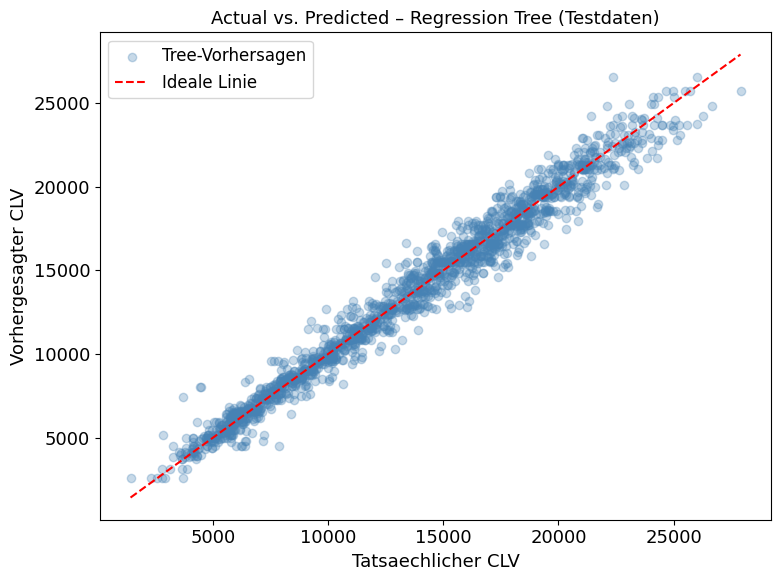

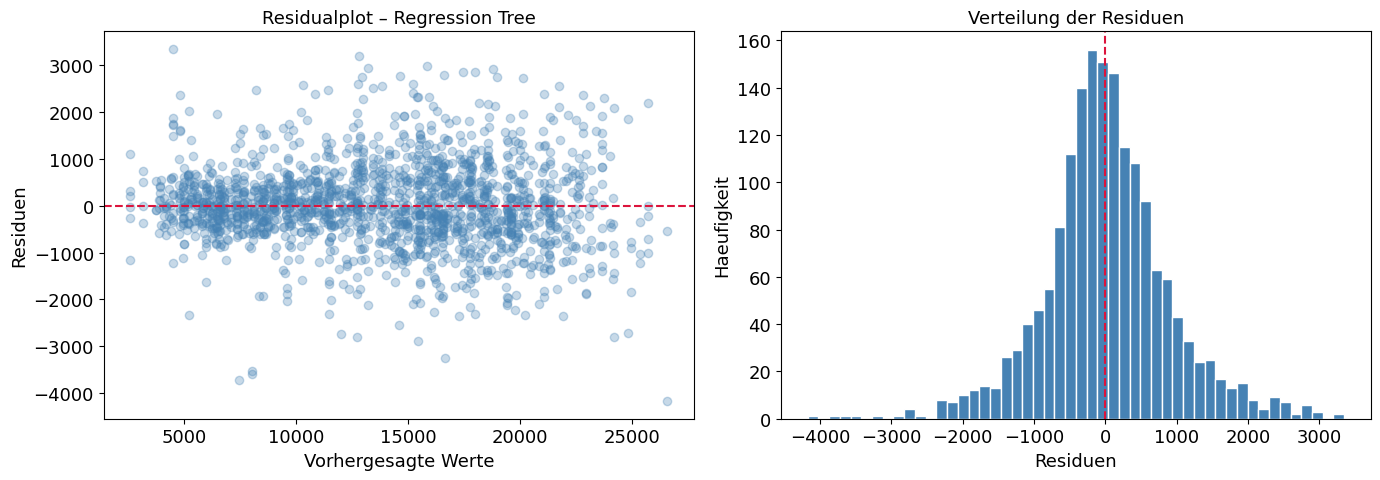

In [21]:
# 4) Actual vs. Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_test_tree, alpha=0.3, color='steelblue', label='Tree-Vorhersagen')
min_val = min(y_test.min(), y_pred_test_tree.min())
max_val = max(y_test.max(), y_pred_test_tree.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Ideale Linie')
plt.xlabel('Tatsaechlicher CLV')
plt.ylabel('Vorhergesagter CLV')
plt.title('Actual vs. Predicted – Regression Tree (Testdaten)')
plt.legend()
plt.tight_layout()
plt.show()

# 5) Residualplot
tree_residuals = y_test - y_pred_test_tree
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_pred_test_tree, tree_residuals, alpha=0.3, color='steelblue')
axes[0].axhline(y=0, color='crimson', linestyle='--')
axes[0].set_xlabel('Vorhergesagte Werte')
axes[0].set_ylabel('Residuen')
axes[0].set_title('Residualplot – Regression Tree')

axes[1].hist(tree_residuals, bins=50, color='steelblue', edgecolor='white')
axes[1].axvline(x=0, color='crimson', linestyle='--')
axes[1].set_xlabel('Residuen')
axes[1].set_ylabel('Haeufigkeit')
axes[1].set_title('Verteilung der Residuen')

plt.tight_layout()
plt.show()

---
### Schritt 6: Learning Curve des optimierten Regressionsbaums

Die Lernkurve zeigt, ob das Modell bei wachsender Datenmenge eher zu Overfitting oder Underfitting neigt.

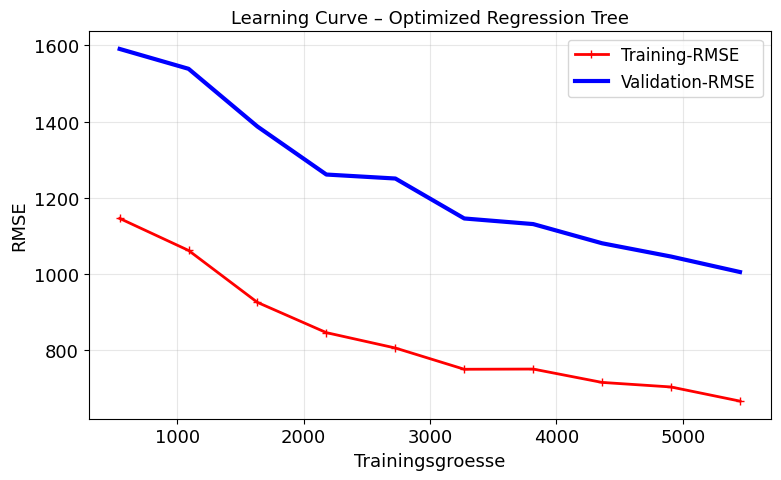

In [22]:
train_sizes, train_scores, valid_scores = learning_curve(
    best_tree_model,
    X_train,
    y_train,
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

train_rmse_curve = -train_scores.mean(axis=1)
valid_rmse_curve = -valid_scores.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_rmse_curve, 'r-+', linewidth=2, label='Training-RMSE')
plt.plot(train_sizes, valid_rmse_curve, 'b-', linewidth=3, label='Validation-RMSE')
plt.xlabel('Trainingsgroesse')
plt.ylabel('RMSE')
plt.title('Learning Curve – Optimized Regression Tree')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
### Schritt 7: Interpretation der Ergebnisse

#### 1. Wirkung des Hyperparameter-Tunings
- Das Basismodell zeigt typisches Overfitting: perfekte Trainingsanpassung, aber deutlich schwaechere Testwerte.
- Durch die Begrenzung der Baumkomplexitaet und die optimierten Hyperparameter verbessert sich die Generalisierung deutlich.

#### 2. Vergleich Baseline vs. optimierter Baum
- **Baseline:** Train-$R^2$ = 1.00, Test-$R^2$ ca. 0.9685, Test-RMSE ca. 969.14
- **Optimierter Baum:** Train-$R^2$ ca. 0.9865, Test-$R^2$ ca. 0.9734, Test-RMSE ca. 889.62
- Das Tuning verbessert die Testleistung spuerbar und reduziert gleichzeitig den Abstand zwischen Trainings- und Testleistung.

#### 3. Overfitting oder Underfitting?
- Das unoptimierte Basismodell **overfittet stark**, da es die Trainingsdaten praktisch auswendig lernt.
- Der optimierte Baum zeigt weiterhin einen Unterschied zwischen Training und Test, aber deutlich weniger stark als die Baseline.
- **Underfitting** liegt nicht vor, da sowohl Train als auch Test relativ gute Werte erzielen.
- Insgesamt liegt eine **moderate Overfitting-Tendenz** vor, die durch Tuning deutlich abgeschwaecht wurde.

#### 4. Interpretation der Visualisierungen
- **Feature Importances:** `CBalance` und `CEstimatedSalary` dominieren die Vorhersage.
- **Baumstruktur:** Die oberen Splits zeigen, welche Variablen den groessten Einfluss auf die Aufteilung des CLV haben.
- **Actual-vs.-Predicted-Plot:** Die Punkte liegen insgesamt nahe an der Ideallinie, mit sichtbaren Abweichungen bei einzelnen Beobachtungen.
- **Residualplot:** Die Residuen streuen um die Nulllinie, allerdings mit einigen Ausreissern.
- **Learning Curve:** Der Abstand zwischen Trainings- und Validierungskurve bleibt sichtbar. Das spricht gegen Underfitting, aber fuer verbleibende Varianz bzw. leichte Ueberanpassung.

#### 5. Schlussfolgerung
- Der optimierte Regressionsbaum ist deutlich besser als die ungetunte Baseline.
- Hyperparameter-Tuning und Cross-Validation verbessern die Generalisierung merklich.
- Das Modell ist leistungsfaehig, aber weniger stabil als die besten linearen bzw. regularisierten Regressionsmodelle aus den vorherigen Tasks.

### Kurzvergleich mit Ridge Regression

Im Vergleich zur optimierten Ridge Regression aus Task 5 erzielt der optimierte Regressionsbaum auf den Testdaten die bessere Leistung (niedrigerer RMSE und höheres $R^2$). Gleichzeitig zeigt die Learning Curve, dass der Baum trotz Tuning noch etwas stärker zur Varianz neigt als Ridge.

**Kurzfazit:**
- **Bestes Modell nach Testleistung:** Optimierter Regressionsbaum
- **Stabileres Modell:** Ridge Regression
- **Pragmatische Schlussfolgerung:** Wenn die reine Vorhersagegüte im Vordergrund steht, ist hier der Regressionsbaum die bessere Wahl.